Objective Of This Project

To apply advanced Python techniques for data transformation, time-series analysis, and feature engineering using historical stock market data.

Dataset

Apple Inc. (AAPL) Historical Stock Market Dataset from Yahoo Finance.


Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import yfinance as yf

# Download historical data for a specific ticker (e.g., Apple)
data = yf.download('AAPL', start='2021-06-08', end='2026-06-08')

# Save the data to a CSV file
data.to_csv('aapl_stock_data.csv')

/tmp/ipykernel_5966/3710738197.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2021-06-08', end='2026-06-08')
[*********************100%***********************]  1 of 1 completed


#1. Data Transformation

- Data cleaning
- Handling missing values
- Filtering and sorting data
- Grouping and aggregation
- Creating calculated columns
- Data formatting and restructuring

In [2]:
# Data Cleaning

# Load the dataset
df = pd.read_csv('aapl_stock_data.csv')

df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-06-08,123.54004669189453,125.21662849111421,123.0234294041827,123.40358202860334,74403800
3,2021-06-09,123.92020416259766,124.52455300706954,123.32560491924683,123.99818609803275,56877900
4,2021-06-10,122.92596435546875,124.95345011953233,122.76025831506651,123.81298472926724,71186400


In [3]:
# Drop unnecessary rows

df.drop([0, 1], inplace=True)

df.head()

,Price,Close,High,Low,Open,Volume
2,2021-06-08,123.54004669189453,125.21662849111421,123.0234294041827,123.40358202860334,74403800
3,2021-06-09,123.92020416259766,124.52455300706954,123.32560491924683,123.99818609803275,56877900
4,2021-06-10,122.92596435546875,124.95345011953233,122.76025831506651,123.81298472926724,71186400
5,2021-06-11,124.13467407226562,124.22240562529288,122.91623399021204,123.3353776759092,53522400
6,2021-06-14,127.18561553955078,127.24409827001125,123.86171564217574,124.5927795199969,96906500


In [4]:
# Rename the column Price to Date

df.rename(columns={'Price': 'Date'}, inplace=True)

df.head()

,Date,Close,High,Low,Open,Volume
2,2021-06-08,123.54004669189453,125.21662849111421,123.0234294041827,123.40358202860334,74403800
3,2021-06-09,123.92020416259766,124.52455300706954,123.32560491924683,123.99818609803275,56877900
4,2021-06-10,122.92596435546875,124.95345011953233,122.76025831506651,123.81298472926724,71186400
5,2021-06-11,124.13467407226562,124.22240562529288,122.91623399021204,123.3353776759092,53522400
6,2021-06-14,127.18561553955078,127.24409827001125,123.86171564217574,124.5927795199969,96906500


In [5]:
# Checking the data for null values

df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [6]:
# Check the data type of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 2 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1255 non-null   object
 1   Close   1255 non-null   object
 2   High    1255 non-null   object
 3   Low     1255 non-null   object
 4   Open    1255 non-null   object
 5   Volume  1255 non-null   object
dtypes: object(6)
memory usage: 59.0+ KB


In [7]:
# Change the date column to date

df['Date']= pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 2 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1255 non-null   datetime64[ns]
 1   Close   1255 non-null   object        
 2   High    1255 non-null   object        
 3   Low     1255 non-null   object        
 4   Open    1255 non-null   object        
 5   Volume  1255 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 59.0+ KB


In [8]:
# Convert all other column to float

df['Open'] = df['Open'].astype(float)
df['High'] = df['High'].astype(float)
df['Low'] = df['Low'].astype(float)
df['Close'] = df['Close'].astype(float)
df['Volume'] = df['Volume'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 2 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1255 non-null   datetime64[ns]
 1   Close   1255 non-null   float64       
 2   High    1255 non-null   float64       
 3   Low     1255 non-null   float64       
 4   Open    1255 non-null   float64       
 5   Volume  1255 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 59.0 KB


In [9]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,1255,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,2023-12-04 23:54:15.776892416,191.574539,193.449540,189.510072,191.365295,6.535056e+07
min,2021-06-08 00:00:00,122.925964,124.222406,122.097738,123.335378,1.791060e+07
25%,2022-09-04 00:00:00,154.330223,156.741538,151.876119,154.634086,4.615660e+07
50%,2023-12-04 00:00:00,180.707397,182.589895,179.202775,180.539085,5.780870e+07
75%,2025-03-06 12:00:00,225.431023,227.356580,223.095100,225.335837,7.751080e+07
max,2026-06-05 00:00:00,315.200012,316.940002,309.649994,314.179993,3.186799e+08
std,NaN,43.954664,44.267631,43.621156,43.935523,2.817909e+07


In [10]:
# date and time manipulation

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day


df.head()

,Date,Close,High,Low,Open,Volume,Year,Month,Day
2,2021-06-08,123.540047,125.216628,123.023429,123.403582,74403800.0,2021,6,8
3,2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900.0,2021,6,9
4,2021-06-10,122.925964,124.953450,122.760258,123.812985,71186400.0,2021,6,10
5,2021-06-11,124.134674,124.222406,122.916234,123.335378,53522400.0,2021,6,11
6,2021-06-14,127.185616,127.244098,123.861716,124.592780,96906500.0,2021,6,14


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 2 to 1256
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1255 non-null   datetime64[ns]
 1   Close   1255 non-null   float64       
 2   High    1255 non-null   float64       
 3   Low     1255 non-null   float64       
 4   Open    1255 non-null   float64       
 5   Volume  1255 non-null   float64       
 6   Year    1255 non-null   int32         
 7   Month   1255 non-null   int32         
 8   Day     1255 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3)
memory usage: 73.7 KB


In [12]:
# Calculate 7-day rolling average for 'Close' price
df['7_day_rolling_avg'] = df['Close'].rolling(window=7).mean()

df.head()

,Date,Close,High,Low,Open,Volume,Year,Month,Day,7_day_rolling_avg
2,2021-06-08,123.540047,125.216628,123.023429,123.403582,74403800.0,2021,6,8,NaN
3,2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900.0,2021,6,9,NaN
4,2021-06-10,122.925964,124.953450,122.760258,123.812985,71186400.0,2021,6,10,NaN
5,2021-06-11,124.134674,124.222406,122.916234,123.335378,53522400.0,2021,6,11,NaN
6,2021-06-14,127.185616,127.244098,123.861716,124.592780,96906500.0,2021,6,14,NaN


In [13]:
# Calculate 30-day rolling average for 'Close' price
df['30_day_rolling_avg'] = df['Close'].rolling(window=30).mean()

df.head()

,Date,Close,High,Low,Open,Volume,Year,Month,Day,7_day_rolling_avg,30_day_rolling_avg
2,2021-06-08,123.540047,125.216628,123.023429,123.403582,74403800.0,2021,6,8,NaN,NaN
3,2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900.0,2021,6,9,NaN,NaN
4,2021-06-10,122.925964,124.953450,122.760258,123.812985,71186400.0,2021,6,10,NaN,NaN
5,2021-06-11,124.134674,124.222406,122.916234,123.335378,53522400.0,2021,6,11,NaN,NaN
6,2021-06-14,127.185616,127.244098,123.861716,124.592780,96906500.0,2021,6,14,NaN,NaN


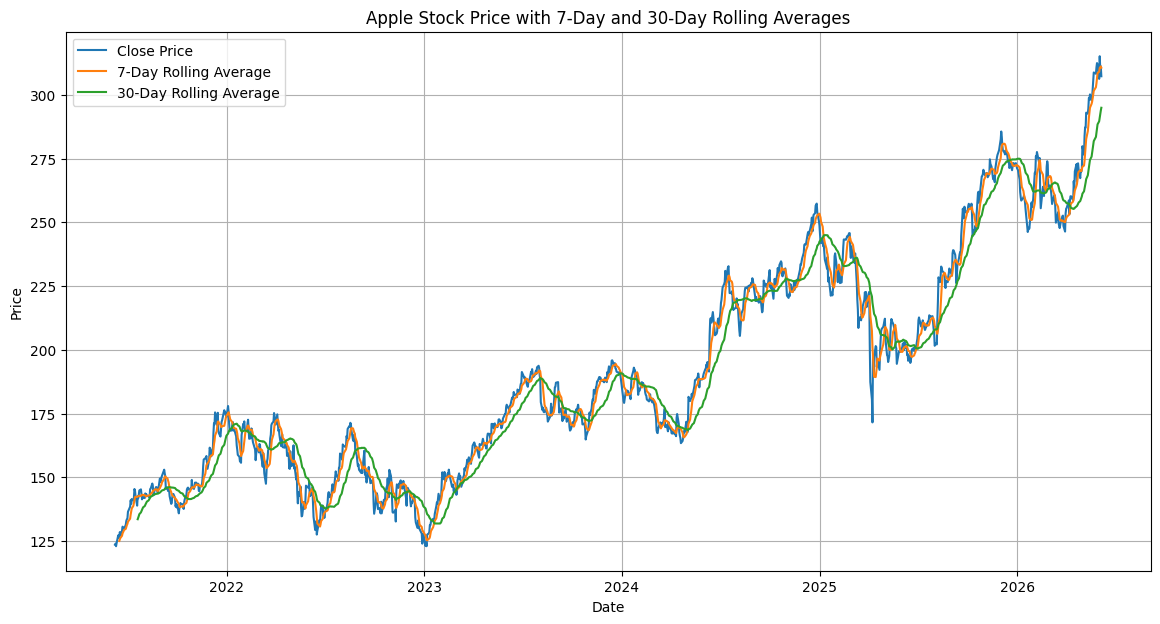

In [14]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Close', label='Close Price')
sns.lineplot(data=df, x='Date', y='7_day_rolling_avg', label='7-Day Rolling Average')
sns.lineplot(data=df, x='Date', y='30_day_rolling_avg', label='30-Day Rolling Average')
plt.title('Apple Stock Price with 7-Day and 30-Day Rolling Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

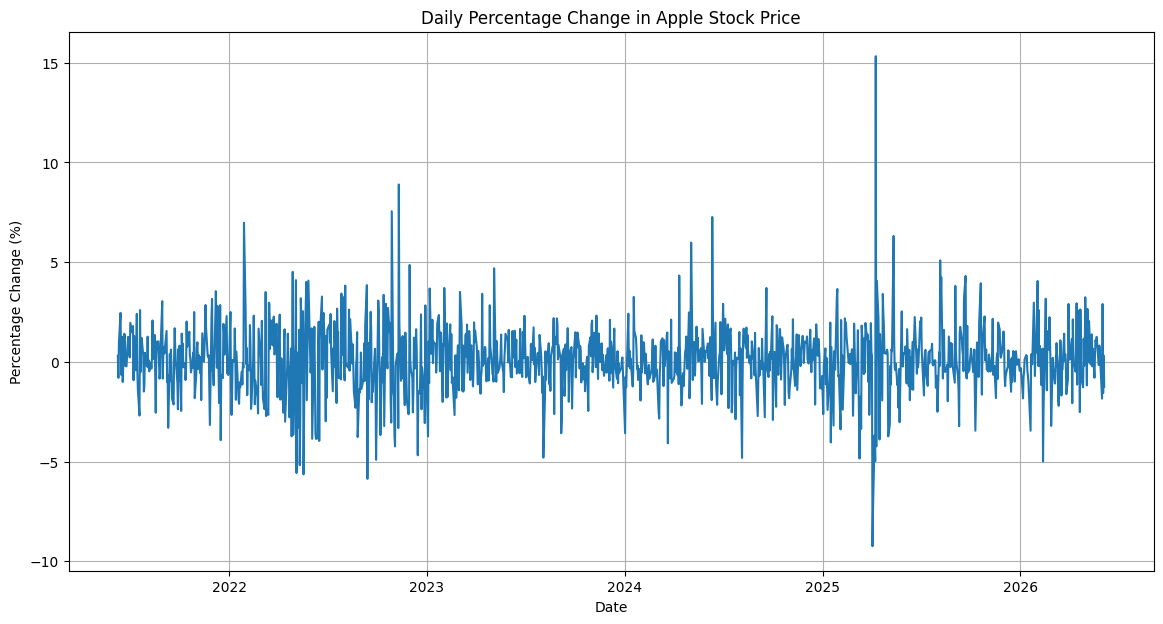

In [15]:
df['Daily_Change'] = df['Close'].diff()
df['Daily_Percentage_Change'] = (df['Close'].pct_change()) * 100

plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Daily_Percentage_Change')
plt.title('Daily Percentage Change in Apple Stock Price')
plt.xlabel('Date')
plt.ylabel('Percentage Change (%)')
plt.grid(True)
plt.show()

Now, let's analyze the monthly performance by looking at the average 'Close' price per month.

/tmp/ipykernel_5966/88132714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg_close, x='Month', y='Close', palette='viridis')


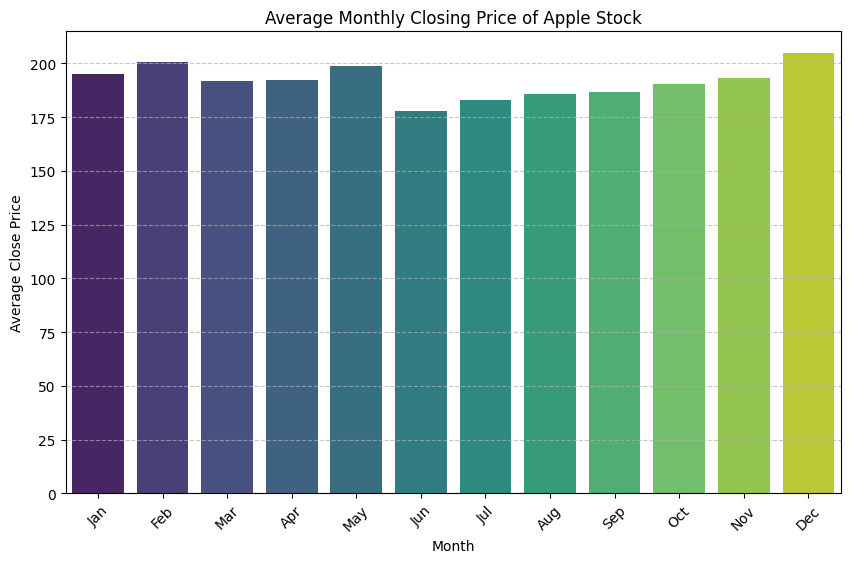

In [16]:
monthly_avg_close = df.groupby('Month')['Close'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg_close, x='Month', y='Close', palette='viridis')
plt.title('Average Monthly Closing Price of Apple Stock')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Monthly Returns Analysis

/tmp/ipykernel_5966/2377478672.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('Date').resample('M')['Close'].last().pct_change() * 100


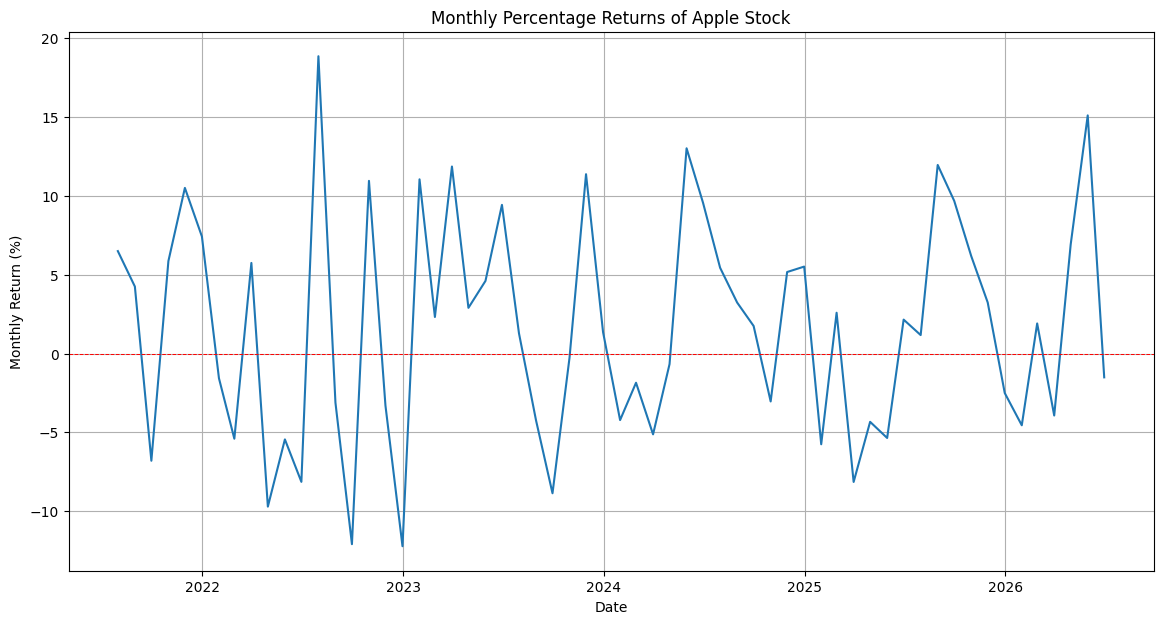

In [17]:
# Calculate monthly returns
df_monthly = df.set_index('Date').resample('M')['Close'].last().pct_change() * 100
df_monthly = df_monthly.reset_index()
df_monthly.rename(columns={'Close': 'Monthly_Return'}, inplace=True)

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_monthly, x='Date', y='Monthly_Return')
plt.title('Monthly Percentage Returns of Apple Stock')
plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.7)
plt.show()

Now let's look at the distribution of these monthly returns to understand their variability.

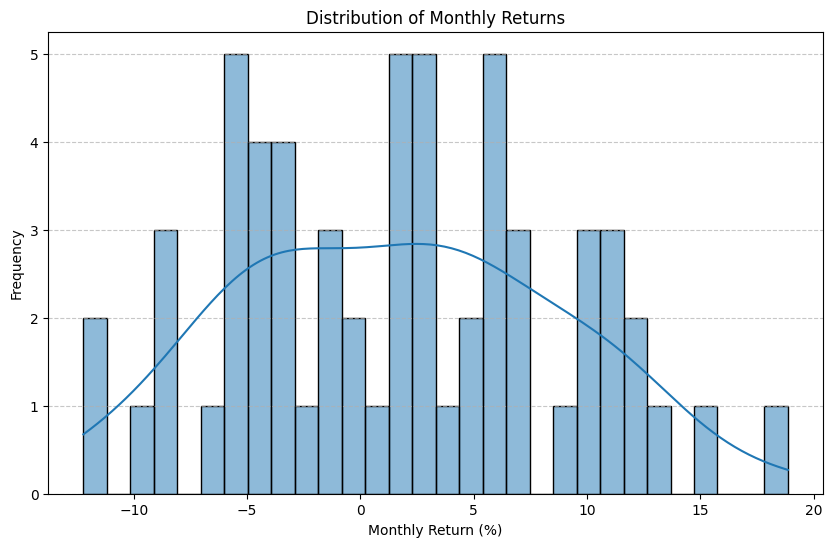

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df_monthly['Monthly_Return'].dropna(), bins=30, kde=True)
plt.title('Distribution of Monthly Returns')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Volatility Measures

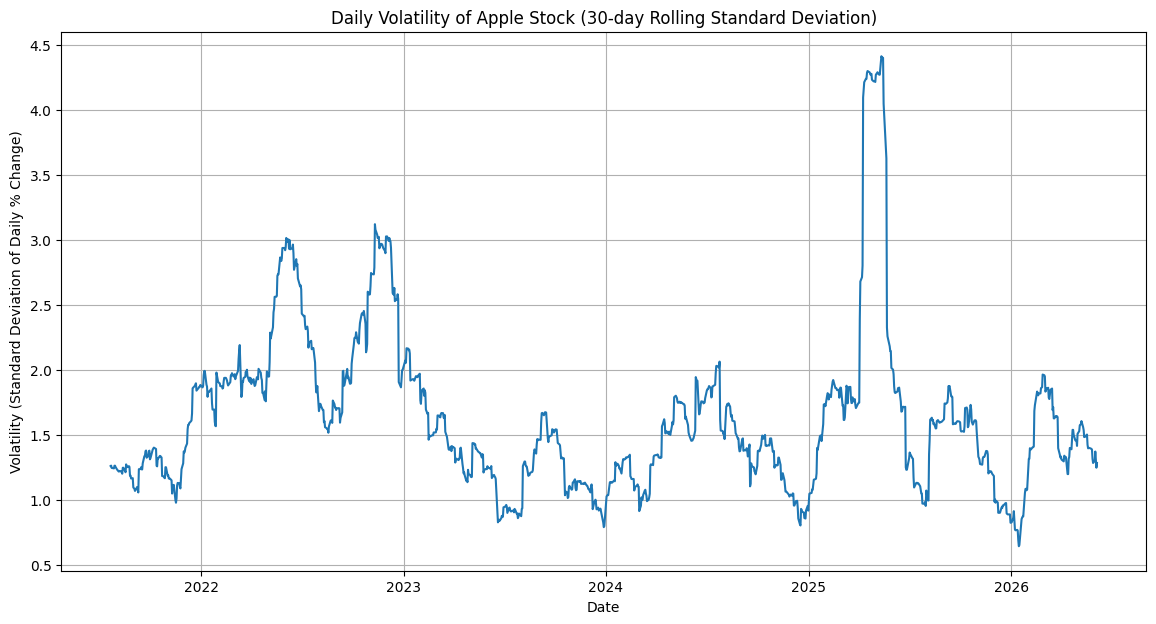

In [19]:
# Calculate daily volatility (e.g., using a 30-day rolling standard deviation of daily percentage change)
df['Daily_Volatility'] = df['Daily_Percentage_Change'].rolling(window=30).std()

plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Daily_Volatility')
plt.title('Daily Volatility of Apple Stock (30-day Rolling Standard Deviation)')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation of Daily % Change)')
plt.grid(True)
plt.show()